<a href="https://colab.research.google.com/github/marieee005/EstadisticaVerano2026/blob/main/GymMembers/U2_Proyecto_Gym_Members.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/marieee005/EstadisticaVerano2026/refs/heads/main/GymMembers/gym_members_exercise_tracking.csv")

df

,Age,Gender,Weight_(kg),Height_(m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration_(hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake_(liters),Workout_Frequency_(days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,Male,87.1,1.74,187,158,67,1.57,1364.0,Strength,10.0,3.5,4,3,28.77
969,25,Male,66.6,1.61,184,166,56,1.38,1260.0,Strength,25.0,3.0,2,1,25.69
970,59,Female,60.4,1.76,194,120,53,1.72,929.0,Cardio,18.8,2.7,5,3,19.50
971,32,Male,126.4,1.83,198,146,62,1.10,883.0,HIIT,28.2,2.1,3,2,37.74


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight_(kg)                    973 non-null    float64
 3   Height_(m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration_(hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake_(liters)          973 non-null    float64
 12  Workout_Frequency_(days/week)  973 non-null    int

In [ ]:
df.dropna(inplace=True)

+ `Age` es del tipo numérico entero.
+ `Gender` es del tipo categórico.
+ `Weight_(kg)` es del tipo numérico con decimales.
+ `Height_(m)` es del tipo numérico con decimales.
+ `Max_BPM` es del tipo numérico entero.
+ `Avg_BPM` es del tipo numérico entero.
+ `Resting_BPM` es del tipo numérico entero.
+ `Session_Duration_(hours)` es del tipo numérico con decimales.
+ `Calories_Burned` es del tipo numérico entero.
+ `Workout_Type` es del tipo categórico.
+ `Fat_Percentage` es del tipo numérico con decimales.
+ `Water_Intake_(liters)` es del tipo numérico con decimales.
+ `Workout_Frequency_(days/week)` es del tipo numérico entero.
+ `Experience_Level` es del tipo numérico entero ordinal.
+ `BMI` es del tipo numérico con decimales.

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
Female   Male  82.2071   0.0 48.2331 116.181   True
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

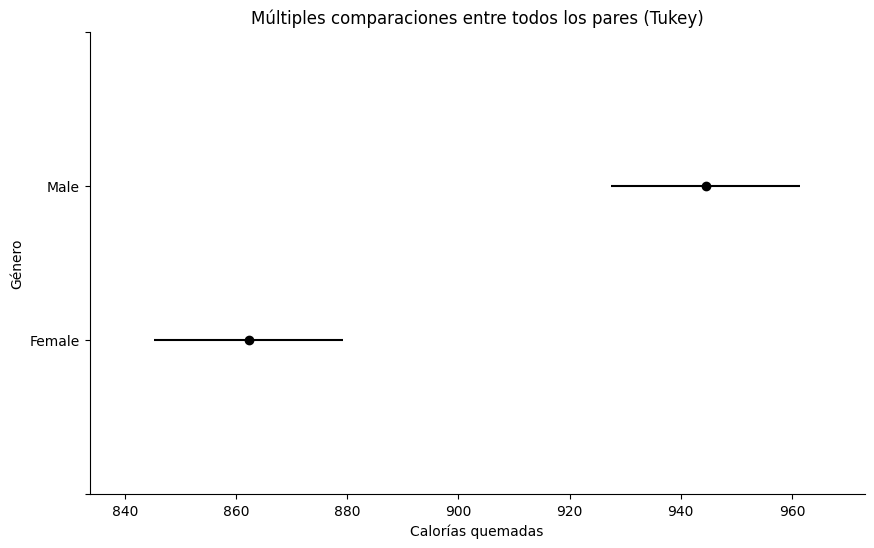

In [ ]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['Calories_Burned'], # Variable de respuesta (simepre se queda en Y)
    groups=df['Gender'],  # Variable categorica nominal
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Género", xlabel="Calorías quemadas")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
df["Gender"] = df["Gender"].map({
    "Female": 0,
    "Male": 1
})

df

,Age,Gender,Weight_(kg),Height_(m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration_(hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake_(liters),Workout_Frequency_(days/week),Experience_Level,BMI
0,56,1,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,0,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,0,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,1,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,1,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,1,87.1,1.74,187,158,67,1.57,1364.0,Strength,10.0,3.5,4,3,28.77
969,25,1,66.6,1.61,184,166,56,1.38,1260.0,Strength,25.0,3.0,2,1,25.69
970,59,0,60.4,1.76,194,120,53,1.72,929.0,Cardio,18.8,2.7,5,3,19.50
971,32,1,126.4,1.83,198,146,62,1.10,883.0,HIIT,28.2,2.1,3,2,37.74


In [ ]:
df.groupby("Workout_Type")["Calories_Burned"].mean()

,Calories_Burned
Workout_Type,
Cardio,884.513725
HIIT,925.805430
Strength,910.697674
Yoga,903.188285


In [ ]:
df["Workout_Type"] = df["Workout_Type"].map({
    "Cardio": 0,
    "HIIT": 1,
    "Strength": 2,
    "Yoga": 3,
})

df

,Age,Gender,Weight_(kg),Height_(m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration_(hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake_(liters),Workout_Frequency_(days/week),Experience_Level,BMI
0,56,1,88.3,1.71,180,157,60,1.69,1313.0,3,12.6,3.5,4,3,30.20
1,46,0,74.9,1.53,179,151,66,1.30,883.0,1,33.9,2.1,4,2,32.00
2,32,0,68.1,1.66,167,122,54,1.11,677.0,0,33.4,2.3,4,2,24.71
3,25,1,53.2,1.70,190,164,56,0.59,532.0,2,28.8,2.1,3,1,18.41
4,38,1,46.1,1.79,188,158,68,0.64,556.0,2,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,1,87.1,1.74,187,158,67,1.57,1364.0,2,10.0,3.5,4,3,28.77
969,25,1,66.6,1.61,184,166,56,1.38,1260.0,2,25.0,3.0,2,1,25.69
970,59,0,60.4,1.76,194,120,53,1.72,929.0,0,18.8,2.7,5,3,19.50
971,32,1,126.4,1.83,198,146,62,1.10,883.0,1,28.2,2.1,3,2,37.74


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    int64  
 2   Weight_(kg)                    973 non-null    float64
 3   Height_(m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration_(hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    int64  
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake_(liters)          973 non-null    float64
 12  Workout_Frequency_(days/week)  973 non-null    int

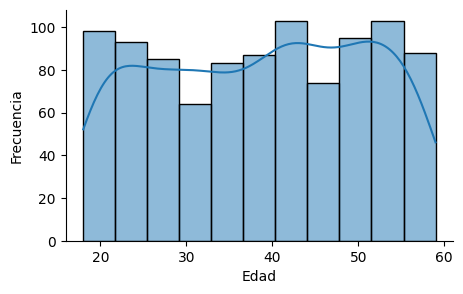

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['Age'], kde=True)
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

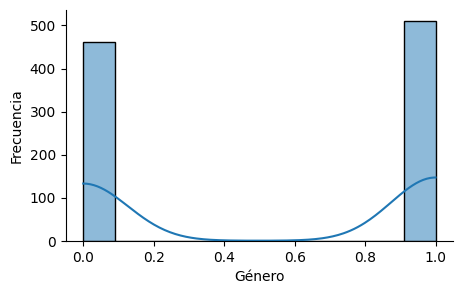

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['Gender'], kde=True)
plt.xlabel("Género")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

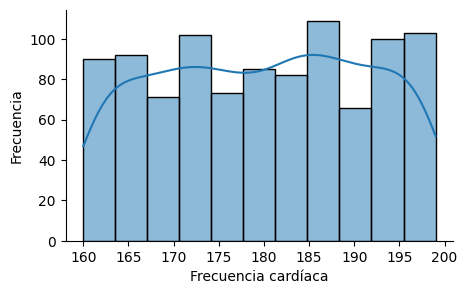

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['Max_BPM'], kde=True)
plt.xlabel("Frecuencia cardíaca")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

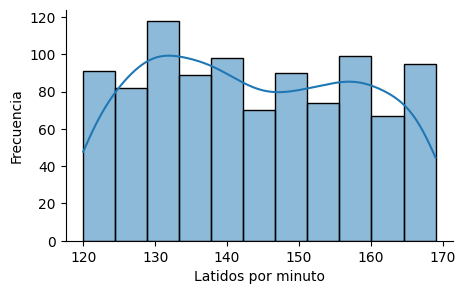

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['Avg_BPM'], kde=True)
plt.xlabel("Latidos por minuto")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

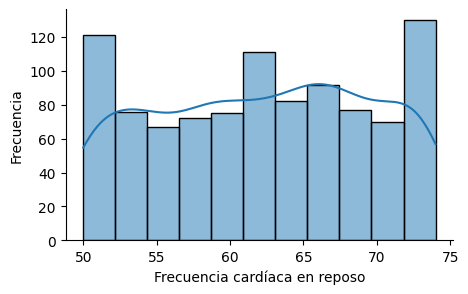

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['Resting_BPM'], kde=True)
plt.xlabel("Frecuencia cardíaca en reposo")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

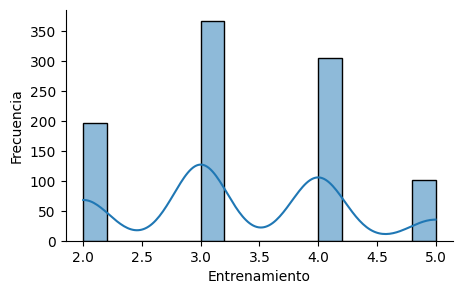

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['Workout_Frequency_(days/week)'], kde=True)
plt.xlabel("Entrenamiento")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

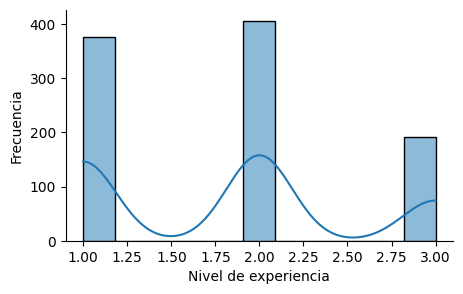

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['Experience_Level'], kde=True)
plt.xlabel("Nivel de experiencia")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

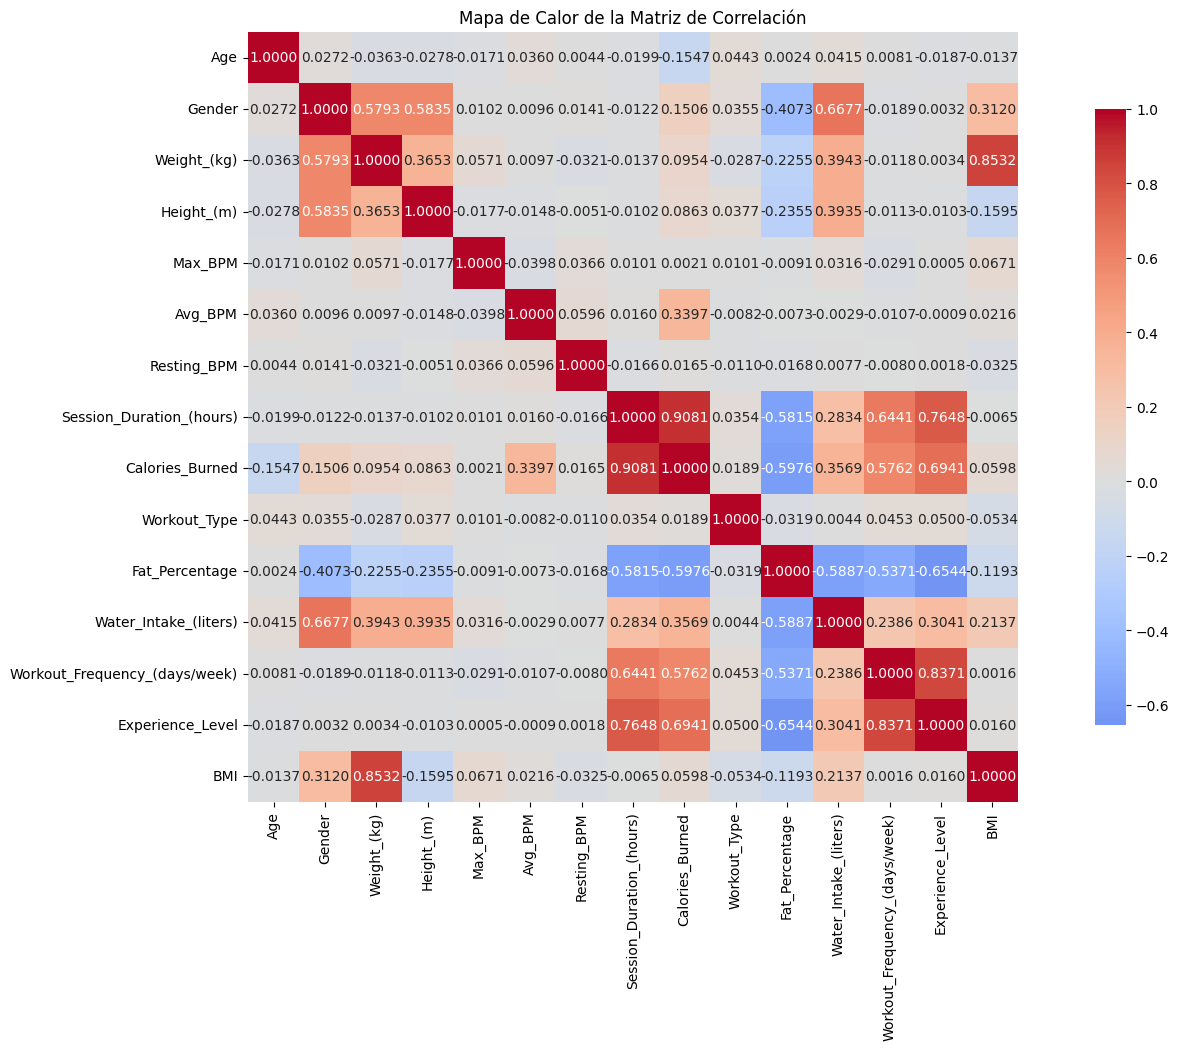

In [ ]:
import seaborn as sns          # Librería para visualización estadística
import matplotlib.pyplot as plt  # Librería base para gráficos

# Calcula la matriz de correlación entre variables numéricas del DataFrame
# Selecciona solo las columnas numéricas para calcular la correlación
correlation_matrix = df.select_dtypes(include=['number']).corr()

plt.figure(
    figsize=(20, 10), # Define el tamaño de la figura (ancho, alto)
    dpi = 100  # Calidad de la imagen dpi=50 (estandar) dpi = 300 (alta calidad)
    )

# Construye el mapa de calor de la matriz de correlación
sns.heatmap(
    correlation_matrix,   # Datos: matriz de correlación
    annot=True,           # Muestra los valores numéricos en cada celda
    cmap='coolwarm',      # Paleta de colores (azul = negativo, rojo = positivo)
    fmt=".4f",            # Formato de los números (4 decimales)
    square=True,          # Hace que cada celda sea cuadrada
    center=0,             # Centra la escala de colores en 0 (muy importante)
    cbar_kws={"shrink": .8}  # Reduce el tamaño de la barra de color
)

# Título del gráfico
plt.title('Mapa de Calor de la Matriz de Correlación')

# Muestra la gráfica en pantalla
plt.show()

In [ ]:
X = df["Session_Duration_(hours)"]
Y = df["Calories_Burned"]

In [ ]:
import statsmodels.api as sm
x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

In [ ]:
# Coeficiente de determinación
from sklearn.metrics import r2_score

r2 = r2_score(Y, y_calculada)

print(f"Coeficiente de determinación: {r2: 0.2%}")

Coeficiente de determinación:  82.47%


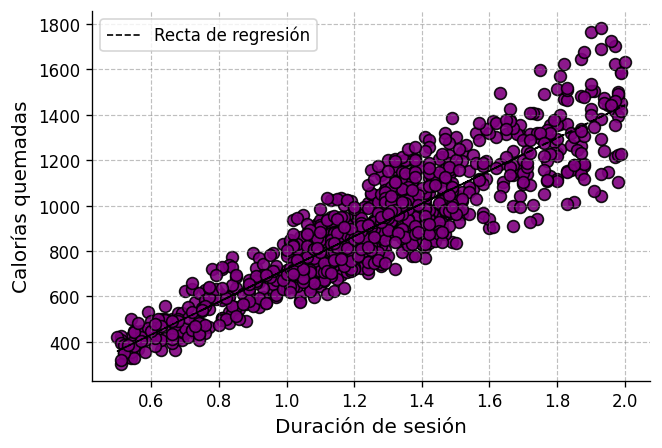

In [ ]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='purple',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Duración de sesión', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Calorías quemadas', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    loc='best',
    fontsize=10
)

In [ ]:
residuales = modelo.resid

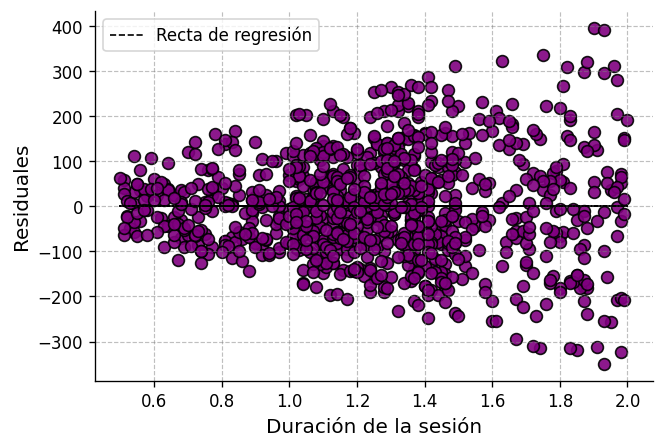

In [ ]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, residuales,      # <--------------------------------------------------------
    marker="o",       # forma: googlear "matplotlib.markers"
    color='purple',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada * 0,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Duración de la sesión', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Residuales', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    fontsize=10,
    loc='best'
)

valor-p (Shapiro) = 0.003841645423152361


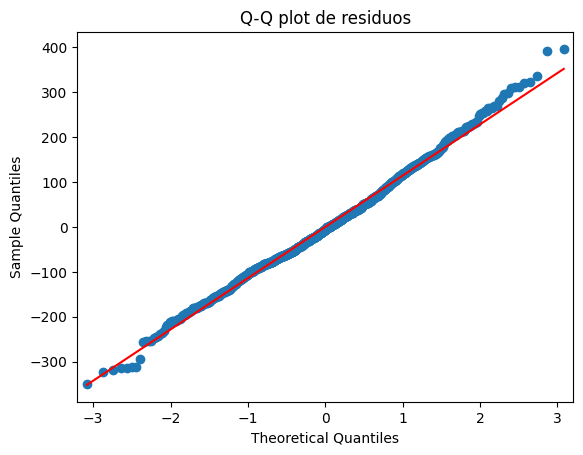

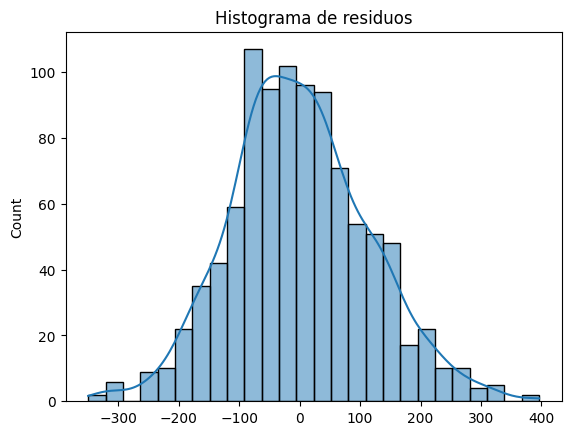

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# n < 30, Shapiro-Wilk es el más confiable
# n >= 30, Histograma o Q-Q plot

# test de Shapiro-Wilk
1
# H0: Hay normalidad    0.4172971767713699
0.05
# H1: No hay normalidad
0

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
# MARIELENA CARVAJAL BECERRA

In [ ]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.0000



In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Y ~ X
modelo_lineal = ols("Q('Calories_Burned') ~ Q('Session_Duration_(hours)')", data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
Q('Session_Duration_(hours)'),1.0,5.958764e+07,5.958764e+07,4568.674447,0.0
Residual,971.0,1.266442e+07,1.304265e+04,NaN,NaN


In [ ]:
# MARIELENA CARVAJAL BECERRA